In [6]:
import matplotlib.pyplot as plt 
import xarray as xr 
import cmocean as cmo 

fn = "/Users/siennawhite/research/scripts/demo_lisa/turbulence-model/demo_for_lisa.nc"
df = xr.open_dataset(fn)

print(df)
z = df.z 
time = df.t 
nt = len(time)
print(time.values)


print(df.nu_t)


<xarray.Dataset>
Dimensions:      (z: 80, t: 29)
Coordinates:
  * z            (z) float64 -9.938 -9.812 -9.688 ... -0.3125 -0.1875 -0.0625
  * t            (t) float64 190.0 390.0 590.0 ... 5.39e+03 5.59e+03 5.79e+03
Data variables:
    U            (z, t) float64 ...
    C            (z, t) float64 ...
    Q2           (z, t) float64 ...
    rho          (z, t) float64 ...
    nu_t         (z, t) float64 ...
    Kz           (z, t) float64 ...
    Kq           (z, t) float64 ...
    N_BV2        (z, t) float64 ...
    algae1       (z, t) float64 ...
    algae2       (z, t) float64 ...
    net_growth1  (z, t) float64 ...
    net_growth2  (z, t) float64 ...
Attributes:
    Px0:                   0.0002
    T_Px:                  1
    I_in:                  350
    Diurnal:               1
    Wind:                  8
    pmax1:                 2.777777777777778e-05
    pmax2:                 2.222222222222222e-06
    ws1:                   -1.4e-05
    ws2:                   1.4e-05
 

Text(0.5, 1.0, '$\\kappa$ (m$^2$/s)')

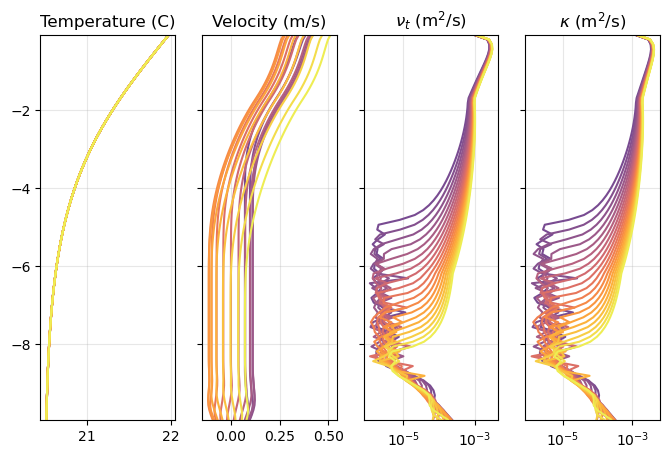

In [7]:
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(8,5), sharey=True)

for t in range(10,nt):
    color = cmo.cm.thermal(t/nt)
    axs[0].plot(df.C.isel(t=t), z, color=color)
    axs[1].plot(df.U.isel(t=t), z, color=color)
    axs[2].plot(df.nu_t.isel(t=t), z, color=color)
    axs[3].plot(df.Kz.isel(t=t), z, color=color)

axs[0].set_ylim(z[0], z[-1])
axs[2].set_xscale('log')
axs[3].set_xscale('log')

for ax in axs:
    ax.grid(alpha=0.3)

axs[0].set_title("Temperature (C)")
axs[1].set_title("Velocity (m/s)")
axs[2].set_title(r"$\nu_t$ (m$^2$/s)")
axs[3].set_title(r"$\kappa$ (m$^2$/s)")

Text(0.5, 1.0, '$Microcystis$')

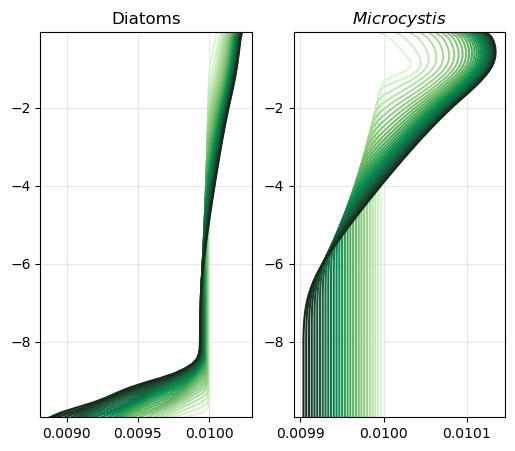

In [8]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6,5))

for t in range(nt):
    color = cmo.cm.algae(t/nt)
    axs[0].plot(df.algae2.isel(t=t), z, color=color) 
    axs[1].plot(df.algae1.isel(t=t), z, color=color)
axs[0].set_ylim(z[0], z[-1])
axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)
axs[0].set_title("Diatoms")
axs[1].set_ylim(z[0], z[-1])
axs[1].set_title("$Microcystis$")

In [9]:
# np.tanh(centered_z * stretch)*dtemp + self.base_temp